In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [7]:
df = pd.read_csv("twitter_training.csv")
df.head()


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [10]:
df.shape

(74681, 4)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [19]:
df.duplicated().sum()

np.int64(2700)

**This data set had a some duplicated values .**

In [18]:
df.isnull().sum()

2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

**One column have a NUll column this will clear after the cleaning.**

In [20]:
df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Text']


In [21]:
print(df.columns)


Index(['Tweet_ID', 'Entity', 'Sentiment', 'Text'], dtype='object')


**Rename this column because this best for understanding.**

In [25]:
df = df.drop_duplicates()

**This duplicated Values or rows are drop.**

In [29]:
df['Text'] = df['Text'].fillna("No content")

C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_13664\194806848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Text'] = df['Text'].fillna("No content")


**The missing value to fill the No content to replace the messing.**

In [33]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        
    text = re.sub(r'@\w+', '', text)         
    text = re.sub(r'#', '', text)             
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)


C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_13664\1084429850.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Clean_Text'] = df['Text'].apply(clean_text)


**Tis is remove and clean the text for best visulization and prediction.**

In [34]:
df = df[df['Clean_Text'] != '']

**Remove and Empty clean text .**

In [36]:
df['Sentiment'].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

In [37]:
df['Sentiment'] = df['Sentiment'].str.strip().str.capitalize()


In [38]:
df = df[df['Sentiment'].isin(['Positive', 'Neutral', 'Negative'])]

- **This some text to convert to titlaze.**
- **If dataset has irrelevant labels, filter**

In [41]:
df.to_csv("cleaned_twitter_training.csv", index=False)


**After cleaing the dataset we can stored the this dataset is another csv file 'cleaned_twitter_training.csv'.**

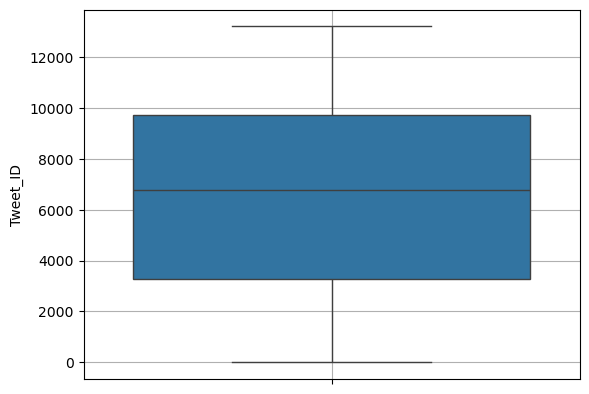

In [42]:
sb.boxplot(df['Tweet_ID'])
plt.grid()

**After cleaing we can finding the outlier in the Numeriacl column 'Tweet_ID'
   but outlier not founded .**

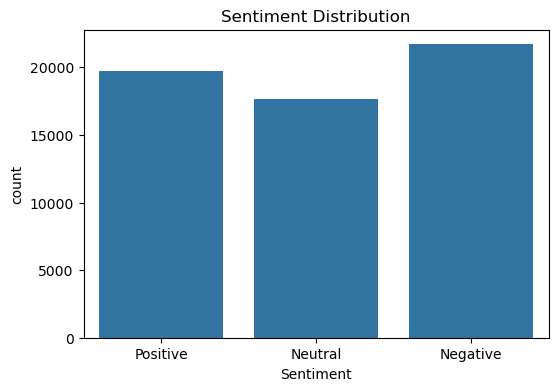

In [46]:
plt.figure(figsize=(6,4))
sb.countplot(x='Sentiment' , data = df)
plt.title('Sentiment Distribution')
plt.show()

- **Which sentiment is highest.**
- **Is public opinion mostly positive or negative.**

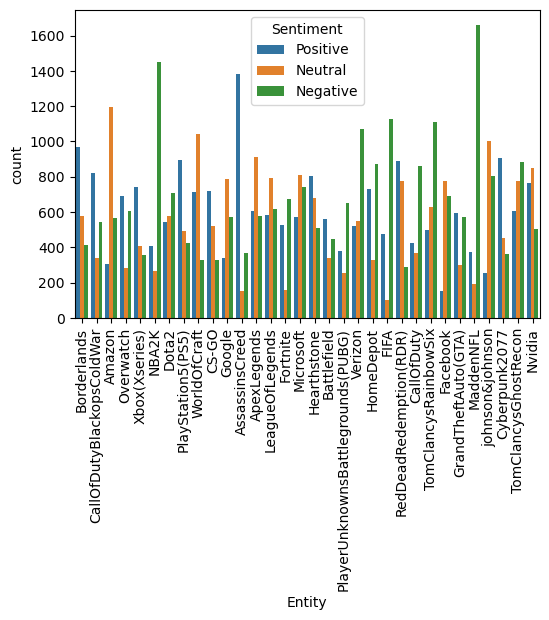

In [45]:
plt.figure(figsize=(6,4))
sb.countplot(x='Entity',hue='Sentiment', data = df)
plt.xticks(rotation = 90)
plt.show()

- **Which brand has most negative sentiment.**
- **Which brand is most positively viewed.**

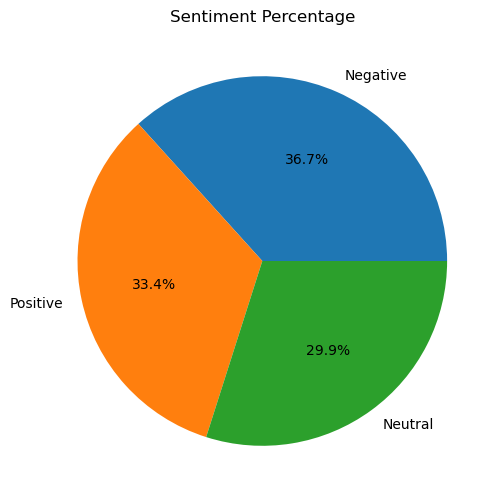

In [47]:
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()


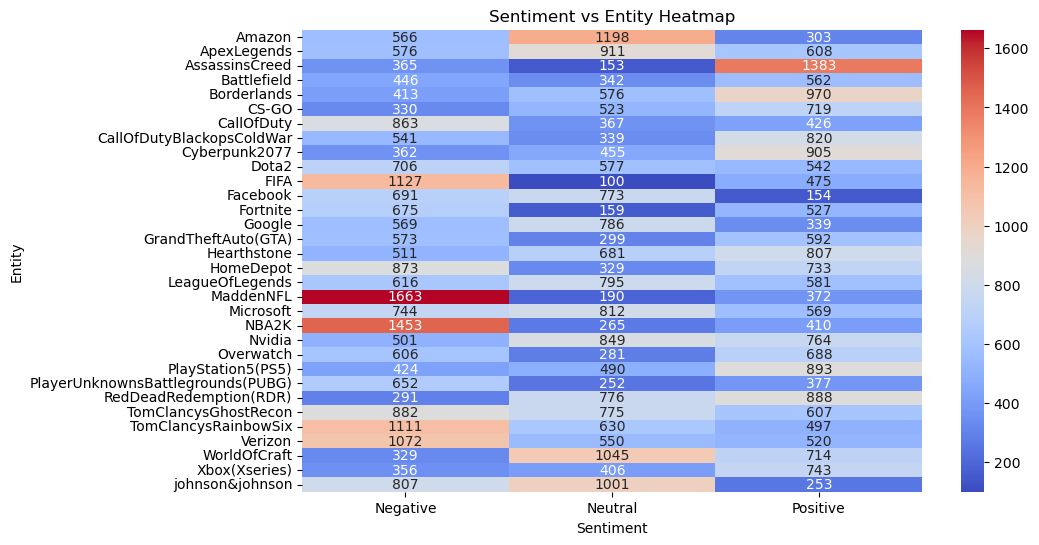

In [49]:
sentiment_entity = pd.crosstab(df['Entity'], df['Sentiment'])

plt.figure(figsize=(10,6))
sb.heatmap(sentiment_entity, annot=True, fmt='d', cmap='coolwarm')
plt.title("Sentiment vs Entity Heatmap")
plt.show()


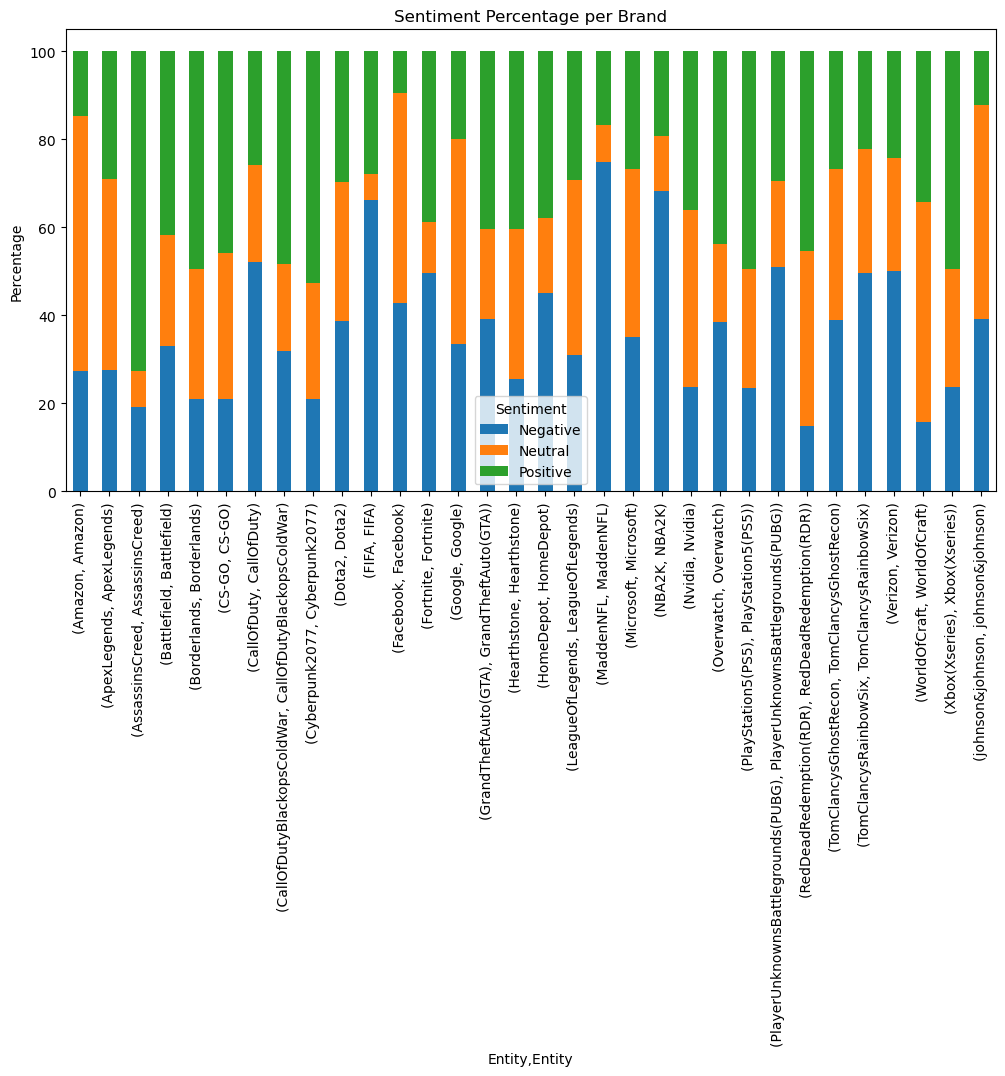

In [51]:
sentiment_percentage = (
    df.groupby(['Entity','Sentiment'])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
)

sentiment_percentage.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Sentiment Percentage per Brand")
plt.ylabel("Percentage")
plt.show()


**✔ Overall Analysis**
    - Majority of tweets are Positive.

    - Around X% tweets are Negative.

    - Irrelevant tweets indicate noise in social media.

**✔ Brand Analysis**

    - Brand A receives high negative sentiment.

    - Brand B has mostly positive feedback.

    - Brand C has high irrelevant mentions.

**✔ Word Analysis**

    - Positive tweets commonly contain words like: “great”, “love”, “best”.

    - Negative tweets often contain: “bad”, “issue”, “problem”.